```{index} single: Pyomo; block
```
```{index} single: Pyomo; kernel library
```
```{index} single: conic optimization; second order cones
```
```{index} single: solver; SCIP
```
```{index} single: application; building insulation
```
# 6.4 Optimal Design of Multilayered Building Insulation


Thermal insulation is installed in buildings to reduce annual energy costs. However, the installation costs money, so the decision of how much insulation to install is a trade-off between the annualized capital costs of insulation and the annual operating costs for heating and air conditioning. This notebook shows the formulation and solution of an optimization problem using conic optimization.

We solve the examples first with the open-source solver SCIP, keeping the models in Pyomo. An optional comparison at the end expresses the same constraints with Pyomo's conic components and solves them with MOSEK.


## Preamble: Install Pyomo and SCIP

The main examples use [SCIP](https://www.scipopt.org/), an open-source solver that handles both nonlinear constraints and binary decisions. No license file or solver account is needed. The next cell installs the packages on Google Colab; in a local notebook, run `%pip install "pyomo>=6.10.1" "pyscipopt>=6.2.1"` once if needed.

Pyomo's `scip_direct` interface uses the [PySCIPOpt Python package](https://pyscipopt.readthedocs.io/en/latest/install.html), whose wheels include SCIP on supported platforms. This is different from the `scip` interface, which requires a separate executable. We use standard Pyomo components for this interface and write the conic inequality as an equivalent quadratic constraint.

SCIP 8.0.3 and later use the Apache 2.0 license; the packages and bundled dependencies retain their own license terms. The optional MOSEK comparison requires a separate installation and license. Ipopt is a continuous solver and cannot enforce the binary layer choices in the multilayer examples.


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "pyomo>=6.10.1" "pyscipopt>=6.2.1"

import pyomo.environ as pyo

SOLVER = pyo.SolverFactory("scip_direct")
assert SOLVER.available(), "Install pyomo>=6.10.1 and pyscipopt>=6.2.1."
SOLVER.options["display/verblevel"] = 0  # keep solver logs out of the notebook
SOLVER.options["numerics/feastol"] = 1e-9
SOLVER.options["limits/gap"] = 1e-8

examples = {}  # retain the data and SCIP solutions for the optional comparison


## Problem description

Consider a wall or surface separating conditioned interior space in a building at temperature $T_i$ from the external environment at temperature $T_o$. Heat conduction through the wall is given by

$$\dot{Q} = UA (T_i - T_o),$$

where $U$ is the overall heat transfer coefficient and $A$ is the heat transfer area. For a wall constructed from $N$ layers of different insulating materials, the inverse of the overall heat transfer coefficient $U$ is given by a sum of serial thermal "resistances"

$$\frac{1}{U} = R_0 + \sum_{n=1}^N R_n,$$

where $R_0$ is the thermal resistance of the structural elements. The thermal resistance of the $n$-th insulating layer is equal to $R_n = \frac{x_n}{k_n}$ for a material with thickness $x_n$ and a thermal conductivity $k_n$, so we can rewrite

$$\frac{1}{U} = R_0 + \sum_{n=1}^N \frac{x_n}{k_n}.$$

The economic objective is to minimize the cost $C$, obtained as the combined annual energy operating expenses and capital cost of insulation. 

We assume the annual energy costs are proportional to overall heat transfer coefficient $U$ and let $\alpha \geq 0$ be the coefficient for the proportional relationship of the overall heat transfer coefficient $U$ to the annual energy costs. Furthermore, we assume the cost of installing a unit area of insulation in the $n$-th layer is given by the affine expression $a_n + b_n x_n$. The combined annualized costs are then

$$C = \alpha U + \beta\sum_{n=1}^N (a_n y_n + b_n x_n),$$

where $\beta$ is a discount factor for the equivalent annualized cost of insulation, and $y_n$ is a binary variable that indicates whether or not layer $n$ is included in the installation. The feasible values for $x_n$ are subject to constraints

$$\begin{align}
x_n & \leq Ty_n \\
\sum_{n=1}^N x_n & \leq T
\end{align}$$

where $T$ is an upper bound on insulation thickness.


## Analytic solution for $N=1$

In the case of a single layer, i.e., $N=1$, we have a one-dimensional cost optimization problem of which we can directly obtain a closed-form analytical solution. Indeed, the expression for the cost $C(x)$ as a function of the thickness $x$ reads

$$\begin{align}
C(x) = \frac{\alpha k}{k R_0 + x} + \beta(a + bx).
\end{align}$$

For a layer that is installed and an interior optimum with $0 < x^* < T$, the parameters $k$, $R_0$, $\beta$, $b$ determine the optimal thickness $x^*$ as

$$x^{*} = - k R_0 + \sqrt{\frac{\alpha k}{\beta b}}.$$

A plot illustrates the trade-off between energy operating costs and capital insulation costs and the corresponding optimal solution $x^*$.


The optimal cost is equal to 4.9962 per sq. meter
The optimal thickness is 0.2864 meters



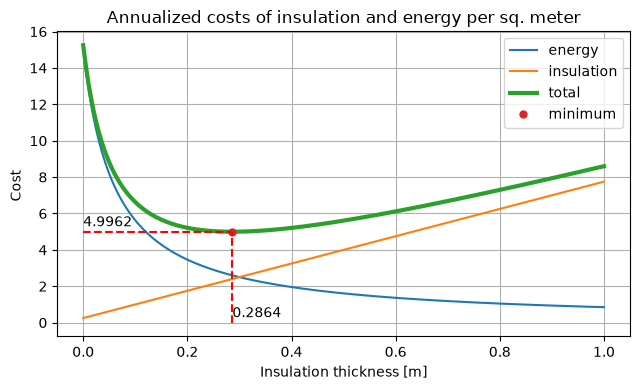

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# application parameters
alpha = 30  # $ K / W annualized cost per sq meter per W/sq m/K
beta = 0.05  # equivalent annual cost factor
R0 = 2.0  # thermal resistance (m**2 K / W)
T = 0.30  # maximum insulation thickness

# material properties
k = 0.030  # thermal conductivity as installed
a = 5.0  # installation cost per square meter
b = 150.0  # installed material cost per cubic meter

f = lambda x: alpha / (R0 + x / k)
g = lambda x: beta * (a + b * x)

# solution
xopt = -k * R0 + np.sqrt(alpha * k / beta / b)

print(f"The optimal cost is equal to {f(xopt) + g(xopt):0.4f} per sq. meter")
print(f"The optimal thickness is {xopt:0.4f} meters\n")

# plotting
x = np.linspace(0, 1, 201)

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))

ax.plot(x, f(x), label="energy")
ax.plot(x, g(x), label="insulation")
ax.plot(x, f(x) + g(x), label="total", lw=3)
ax.plot(xopt, f(xopt) + g(xopt), ".", ms=10, label="minimum")
ax.legend()

ax.plot([0, xopt], [f(xopt) + g(xopt)] * 2, "r--")
ax.plot([xopt] * 2, [0, f(xopt) + g(xopt)], "r--")
ax.text(0, f(xopt) + g(xopt) + 0.3, f"{f(xopt) + g(xopt):0.4f}")
ax.text(xopt, 0.3, f"{xopt:0.4f}")

ax.set_xlabel("Insulation thickness [m]")
ax.set_ylabel("Cost ")
ax.set_title("Annualized costs of insulation and energy per sq. meter")

ax.grid(True)
plt.tight_layout()
plt.show()

## Pyomo model for $N=1$, solved with SCIP

A rotated second-order cone has the form

$$\sum_{n=0}^{N-1} z_n^2 \leq 2 r_1 r_2$$ 

where $r_1$, $r_2$, and $z_0, z_1, \ldots, z_{N-1}$ are variables. For a single layer Pyomo model we identify $R \sim r_1$, $U\sim r_2$, and $z_0^2 \sim 2$ which leads to the model

$$
\begin{align}
\min \quad & \alpha U + \beta(a + bx)\\
\text{s.t.} \quad 
& R = R_0 + \frac{x}{k} \\
& z^2 \leq 2 R U & \text{(conic constraint)}\\
& z = \sqrt{2} \\
& x \leq T\\
& x, R, U \geq 0.
\end{align}
$$

With $z=\sqrt{2}$, the conic inequality is simply $RU \geq 1$. We express it using a standard Pyomo `Constraint` and let SCIP solve the resulting quadratic model. For positive $R$ and $U$, this is the same convex feasible set as the rotated cone; writing a product does not change the model. The optional MOSEK implementation below uses the cone component directly.

The physical bounds are $R_0 \leq R \leq R_0+T/k$ and $1/(R_0+T/k) \leq U \leq 1/R_0$. Restricting the epigraph variable $U$ to this range retains an optimum: the objective increases with $U$ and attains its minimum at $U=1/R$.

In [3]:
m = pyo.ConcreteModel()

# decision variables and physical bounds
m.R = pyo.Var(bounds=(R0, R0 + T / k))
m.U = pyo.Var(bounds=(1 / (R0 + T / k), 1 / R0))
m.x = pyo.Var(bounds=(0, T))

# objective and insulation model
m.cost = pyo.Objective(expr=alpha * m.U + beta * (a + b * m.x))
m.r = pyo.Constraint(expr=m.R == R0 + m.x / k)
m.q = pyo.Constraint(expr=m.R * m.U >= 1)  # equivalent rotated cone

results = SOLVER.solve(m)
pyo.assert_optimal_termination(results)

print(f"The optimal cost is equal to {m.cost():0.5f} per sq. meter")
print(f"The optimal thickness is xopt = {m.x():0.5f} meters")
single_data = pd.DataFrame({"Insulation": {"k": k, "a": a, "b": b}}).T
examples["Single layer"] = (single_data, alpha, beta, R0, T, m)


The optimal cost is equal to 4.99615 per sq. meter
The optimal thickness is xopt = 0.28641 meters


## Multi-Layer Solutions as a Mixed Integer Quadratic Constraint Optimization (MIQCO)

For multiple layers, we cannot easily find an analytical optimal layer composition and must resort to conic optimization. Let $y_n$ be the binary variable that indicates whether layer $n$ is included in the insulation package or not, and $x_n$ be the continuous variable describing the thickness of layer $n$, which is zero if layer $n$ is not included. 

In the general case with $N$ layers, the objective function is given by 

$$
\frac{\alpha}{R} +  \beta \sum_{n=1}^N (a_n y_n + b_n x_n),
$$

where the first term is nonlinear in the variables $x_1,\dots,x_N$ since the denominator of the first term is equal to

$$
R = R_0 + \sum_{n=1}^N \frac{x_n}{k_n}.
$$

To overcome this issue, we can include $U$ as a decision variable and include a constraint

$$
\frac{1}{R} \leq U.
$$

Since $\alpha > 0$ and we minimize the objective, $U$ is equal to $1/R$ at an optimum. The extra constraint $RU \geq 1$ can be reformulated using an extra decision variable $z$ as:

$$
1 \leq RU \quad \Longleftrightarrow \quad \left\{ \begin{array}{l} z^2 \leq 2RU \\
z = \sqrt{2} 
\end{array}
\right.
\quad \Longleftrightarrow
\quad \left\{ \begin{array}{l} \left\|  \begin{array}{c}
\sqrt{2} z \\
R - U
\end{array}\right\|_2 \leq R + U \\
z = \sqrt{2}
\end{array}
\right.
$$

from which we see that the whole problem can be reformulated as a conic optimization problem. 

For SCIP, we again write $RU \geq 1$ as a quadratic constraint in standard Pyomo. For the optional MOSEK comparison, Pyomo's [rotated cone component](https://pyomo.readthedocs.io/en/stable/reference/topical/kernel/conic.html) expresses $z^2 \leq 2RU$ with $z=\sqrt{2}$ directly. Both implementations retain the binary decisions.

Adopting this formulation, the full multilayer building insulation optimization problem then reads:

$$
\begin{align}
\min \quad & \alpha U + \beta \sum_{n=1}^N (a_ny_n + b_nx_n)\\
\text{s.t.} \quad 
& R = R_0 + \sum_{n=1}^N\frac{x_n}{k_n} \\
& x_n \leq T y_n & n=1,\dots,N \\
& \sum_{n=1}^N x_n \leq T \\
& z^2  \leq 2 R U \\
& z  = \sqrt{2} \\
& R, U  > 0\\
& x_n  \geq 0 & n=1,\dots,N \\
& y_n  \in \{0,1\} & n=1,\dots,N
\end{align}
$$

The implementation bounds $R$ above by $R_0+T/\min_n k_n$ and bounds $U$ by the corresponding reciprocal range, using the same reasoning as in the single-layer case. After each solve we check termination and integrality before displaying the solution.


In [4]:
def insulate(df, alpha, beta, R0, T):
    m = pyo.ConcreteModel()
    m.N = pyo.Set(initialize=df.index)
    a, b, k = df["a"], df["b"], df["k"]
    Rmax = R0 + T / k.min()

    # decision variables and physical bounds
    m.R = pyo.Var(bounds=(R0, Rmax))
    m.U = pyo.Var(bounds=(1 / Rmax, 1 / R0))
    m.x = pyo.Var(m.N, bounds=(0, T))
    m.y = pyo.Var(m.N, domain=pyo.Binary)

    m.cost = pyo.Objective(
        expr=alpha * m.U + beta * sum(a[n] * m.y[n] + b[n] * m.x[n] for n in m.N)
    )
    m.insulation = pyo.Constraint(expr=m.R == R0 + sum(m.x[n] / k[n] for n in m.N))
    m.thickness = pyo.Constraint(expr=sum(m.x[n] for n in m.N) <= T)
    m.layers = pyo.Constraint(m.N, rule=lambda m, n: m.x[n] <= T * m.y[n])
    m.q = pyo.Constraint(expr=m.R * m.U >= 1)
    return m


def solve_insulation(m):
    results = SOLVER.solve(m)
    pyo.assert_optimal_termination(results)
    assert all(abs(m.y[n]() - round(m.y[n]())) <= 1e-6 for n in m.N), (
        "The solver returned a nonbinary layer choice."
    )
    lower, upper = results.problem.lower_bound, results.problem.upper_bound
    gap = abs(upper - lower) / max(1, abs(upper))
    print(f"SCIP objective bounds: [{lower:.8f}, {upper:.8f}]; gap: {gap:.2e}")
    return results


### Case 1. Single Layer Solution

The solver chooses which materials to install. The results show both the binary choice (`y opt`) and the thickness (`x opt`, in meters).


In [5]:
# application parameters
alpha = 30  # $ K / W annualized cost per sq meter per W/sq m/K
beta = 0.05  # equivalent annual cost factor
R0 = 2.0  # thermal resistance (m**2 K / W)
T = 0.30  # maximum insulation thickness

df = pd.DataFrame(
    {
        "Mineral Wool": {"k": 0.030, "a": 5.0, "b": 150.0},
        "Rigid Foam (high R)": {"k": 0.015, "a": 8.0, "b": 180.0},
        "Rigid Foam (low R)": {"k": 0.3, "a": 8.0, "b": 120.0},
    }
).T

m = insulate(df, alpha, beta, R0, T)
results = solve_insulation(m)

for n in m.N:
    df.loc[n, "y opt"] = round(m.y[n]())
    df.loc[n, "x opt"] = m.x[n]()
print(f"The optimal cost is equal to {m.cost():0.4f} per sq. meter")
display(df.round(5))
examples["Case 1"] = (df[["k", "a", "b"]].copy(), alpha, beta, R0, T, m)


SCIP objective bounds: [4.15492235, 4.15492236]; gap: 1.94e-09
The optimal cost is equal to 4.1549 per sq. meter


,k,a,b,y opt,x opt
Mineral Wool,0.030,5.0,150.0,0.0,0.00000
Rigid Foam (high R),0.015,8.0,180.0,1.0,0.19361
Rigid Foam (low R),0.300,8.0,120.0,0.0,0.00000


### Case 2. Multiple Layer Solution

In [6]:
# application parameters
alpha = 30  # $ K / W annualized cost per sq meter per W/sq m/K
beta = 0.05  # equivalent annual cost factor
R0 = 2.0  # thermal resistance (m**2 K / W)
T = 0.15  # maximum insulation thickness

df = pd.DataFrame(
    {
        "Foam": {"k": 0.015, "a": 0.0, "b": 110.0},
        "Wool": {"k": 0.010, "a": 0.0, "b": 200.0},
    }
).T

m = insulate(df, alpha, beta, R0, T)
results = solve_insulation(m)

for n in m.N:
    df.loc[n, "y opt"] = round(m.y[n]())
    df.loc[n, "x opt"] = m.x[n]()
print(f"The optimal cost is equal to {m.cost():0.4f} per sq. meter")
display(df.round(5))
examples["Case 2"] = (df[["k", "a", "b"]].copy(), alpha, beta, R0, T, m)


SCIP objective bounds: [3.22992233, 3.22992235]; gap: 8.12e-09
The optimal cost is equal to 3.2299 per sq. meter


,k,a,b,y opt,x opt
Foam,0.015,0.0,110.0,1.0,0.06279
Wool,0.010,0.0,200.0,1.0,0.08721


The plot below gives a graphical representation of the 2-layer problem we just solved. The green line represents the thickness constraint $x_0+x_1 \leq T$, the curves are the isolines of the objective function, and the optimal solution $x^*=(x_0^*,x_1^*)$ is highlighted in red.

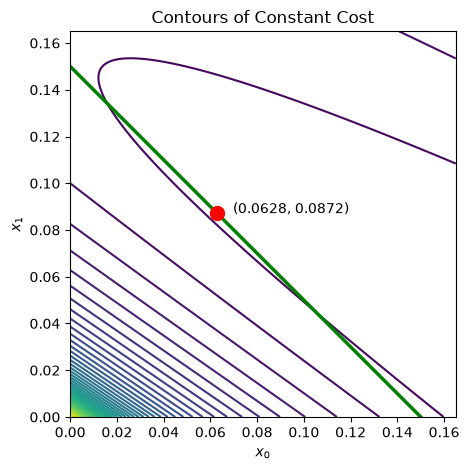

In [7]:
k = list(df["k"])
a = list(df["a"])
b = list(df["b"])

f = lambda x0, x1: alpha / (R0 + x0 / k[0] + x1 / k[1]) + beta * (
    a[0] + b[0] * x0 + a[1] + b[1] * x1
)

x0 = np.linspace(0, 1.1 * T, 201)
x1 = np.linspace(0, 1.1 * T, 201)

X0, X1 = np.meshgrid(x0, x1)

fig, ax = plt.subplots(1, 1)
ax.contour(x0, x1, f(X0, X1), 50)
ax.set_xlim(min(x0), max(x0))
ax.set_ylim(min(x1), max(x1))
ax.plot([0, T], [T, 0], "g", lw=2.5)

ax.set_aspect(1)

x = list(m.x[n]() for n in m.N)
ax.plot(x[0], x[1], "r.", ms=20)
ax.text(x[0], x[1], f"    ({x[0]:0.4f}, {x[1]:0.4f})")

ax.set_xlabel(r"$x_0$")
ax.set_ylabel(r"$x_1$")
ax.set_title("Contours of Constant Cost")
plt.tight_layout()
plt.show()

## Optional comparison: native conic components with MOSEK

The SCIP route above is sufficient for every example. This optional section shows how the same models look in Pyomo's `kernel` library, a set of modeling components with explicit cone constructors. Here `rotated_quadratic.as_domain(R, U, [sqrt(2)])` builds $2 \leq 2RU$ together with the cone's nonnegative-domain conditions. MOSEK recognizes these cone components directly.

To run this comparison locally, install MOSEK with `%pip install mosek` and configure a license as described in the [MOSEK documentation](https://docs.mosek.com/latest/install/installation.html). [Academic licenses](https://www.mosek.com/products/academic-licenses/) are available for eligible use. Keep license files private. No license information is stored in this notebook.

The function below is the conic counterpart of `insulate`. For the continuous single-layer example we fix its sole installation decision to one, matching the analytic model's assumption that the layer is installed. Set `RUN_MOSEK = True` in the final cell to solve all three examples and compare costs. Small differences in thickness can occur within numerical tolerances, even when costs agree closely.


In [8]:
import pyomo.kernel as pmo


def insulate_conic(df, alpha, beta, R0, T):
    m = pmo.block()
    m.N = df.index
    a, b, k = df["a"], df["b"], df["k"]

    m.R = pmo.variable(lb=0)
    m.U = pmo.variable(lb=0)
    m.x = pmo.variable_dict({n: pmo.variable(lb=0) for n in m.N})
    m.y = pmo.variable_dict({n: pmo.variable(domain=pmo.Binary) for n in m.N})
    m.cost = pmo.objective(
        alpha * m.U + beta * sum(a[n] * m.y[n] + b[n] * m.x[n] for n in m.N)
    )
    m.insulation = pmo.constraint(m.R == R0 + sum(m.x[n] / k[n] for n in m.N))
    m.thickness = pmo.constraint(sum(m.x[n] for n in m.N) <= T)
    m.layers = pmo.constraint_dict(
        {n: pmo.constraint(m.x[n] <= T * m.y[n]) for n in m.N}
    )
    m.q = pmo.conic.rotated_quadratic.as_domain(m.R, m.U, [np.sqrt(2)])
    return m


In [9]:
RUN_MOSEK = False  # optional: enable after configuring a local MOSEK license

if RUN_MOSEK:
    MOSEK = pmo.SolverFactory("mosek_direct")
    assert MOSEK.available(), "Install MOSEK and configure a valid license."
    comparisons = []
    mosek_models = {}
    for label, (data, alpha_, beta_, R0_, T_, scip_model) in examples.items():
        conic_model = insulate_conic(data, alpha_, beta_, R0_, T_)
        if label == "Single layer":
            conic_model.y["Insulation"].fix(1)
        result = MOSEK.solve(conic_model)
        pyo.assert_optimal_termination(result)
        assert all(abs(conic_model.y[n]() - round(conic_model.y[n]())) <= 1e-6
                   for n in conic_model.N)
        difference = abs(conic_model.cost() - scip_model.cost())
        assert difference <= 1e-5, "Investigate the difference between solvers."
        comparisons.append({"Example": label, "SCIP cost": scip_model.cost(),
                            "MOSEK cost": conic_model.cost(), "Difference": difference})
        mosek_models[label] = conic_model
    display(pd.DataFrame(comparisons).set_index("Example"))
else:
    print("Optional MOSEK comparison not run; all main examples use SCIP.")


Optional MOSEK comparison not run; all main examples use SCIP.


## Bibliographic Notes

To the best of my knowledge, this problem is not well-known example in the mathematical optimization literature. There are a number of application papers with differing levels of detail. 

> Hasan, A. (1999). Optimizing insulation thickness for buildings using life cycle cost. Applied energy, 63(2), 115-124. https://www.sciencedirect.com/science/article/pii/S0306261999000239

> Kaynakli, O. (2012). A review of the economical and optimum thermal insulation thickness for building applications. Renewable and Sustainable Energy Reviews, 16(1), 415-425. https://www.sciencedirect.com/science/article/pii/S1364032111004163

> Nyers, J., Kajtar, L., Tomić, S., & Nyers, A. (2015). Investment-savings method for energy-economic optimization of external wall thermal insulation thickness. Energy and Buildings, 86, 268-274.  https://www.sciencedirect.com/science/article/pii/S0378778814008688

More recently some modeling papers have appeared

> Gori, P., Guattari, C., Evangelisti, L., & Asdrubali, F. (2016). Design criteria for improving insulation effectiveness of multilayer walls. International Journal of Heat and Mass Transfer, 103, 349-359. https://www.sciencedirect.com/science/article/abs/pii/S0017931016303647

> Huang, H., Zhou, Y., Huang, R., Wu, H., Sun, Y., Huang, G., & Xu, T. (2020). Optimum insulation thicknesses and energy conservation of building thermal insulation materials in Chinese zone of humid subtropical climate. Sustainable Cities and Society, 52, 101840. https://www.sciencedirect.com/science/article/pii/S221067071931457X

> Söylemez, M. S., & Ünsal, M. (1999). Optimum insulation thickness for refrigeration applications. Energy Conversion and Management, 40(1), 13-21. https://www.sciencedirect.com/science/article/pii/S0196890498001253

> Açıkkalp, E., & Kandemir, S. Y. (2019). A method for determining optimum insulation thickness: Combined economic and environmental method. Thermal Science and Engineering Progress, 11, 249-253. https://www.sciencedirect.com/science/article/pii/S2451904918305377

> Ylmén, P., Mjörnell, K., Berlin, J., & Arfvidsson, J. (2021). Approach to manage parameter and choice uncertainty in life cycle optimisation of building design: Case study of optimal insulation thickness. Building and Environment, 191, 107544. https://www.sciencedirect.com/science/article/pii/S0360132320309112